In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style('darkgrid')

In [2]:
pal = sns.color_palette(palette='icefire')
pal_energy      = pal[1]
pal_energy_best = pal[0]
pal_runtime     = pal[5]

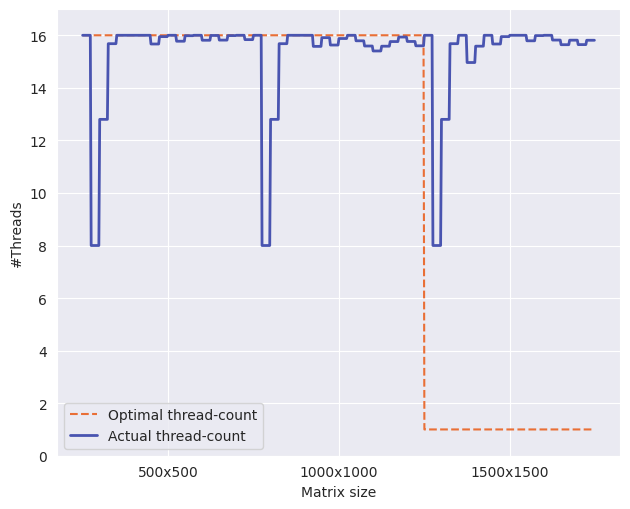

Average distance from optimum: 5.1833


In [3]:
df = pd.read_csv('data/sac_adapt_matmul.csv')
def optimum(row):
    match row['size']:
        case 500: return 16
        case 1000: return 16
        case 1500: return 1
df['optimum'] = df.apply(optimum, axis=1)

fig = plt.figure(figsize=(6.4, 5.2))

x = df.index

ax = sns.lineplot(x=x, y=df['optimum'], label='Optimal thread-count', color=pal_runtime, linestyle='--')
sns.lineplot(x=x, y=df['threads'], label='Actual thread-count', color=pal_energy, linewidth=2, ax=ax)

xticks = list(range(100, len(df), 200))
xlabels = [f'{df['size'][x]}x{df['size'][x]}' for x in xticks]
ax.set_xticks(xticks, labels=xlabels)

ax.set_xlabel('Matrix size')
ax.set_ylabel('#Threads')
ax.set_ylim((0,17))

fig.tight_layout()
fig.savefig('images/sac_adapt_matmul.png', bbox_inches='tight')
plt.show()

dist = (round(df['threads']) - df['optimum']).abs()
print(f'Average distance from optimum: {dist.sum() / len(dist):.4f}')

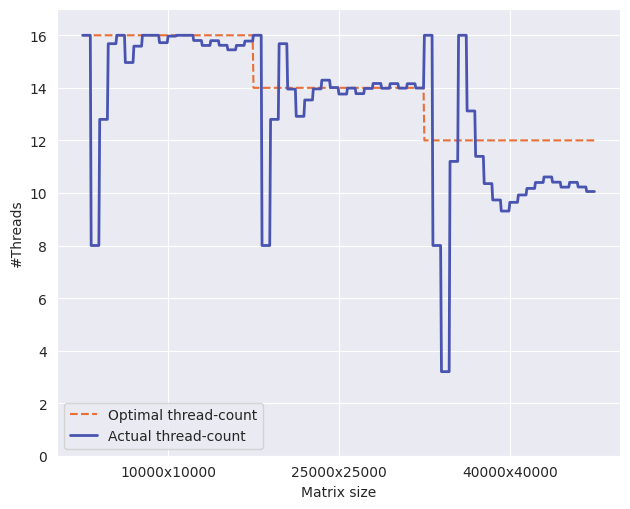

Average distance from optimum: 1.2500


In [4]:
df = pd.read_csv('data/sac_adapt_relax.csv')
def optimum(row):
    match row['size']:
        case 10000: return 16
        case 25000: return 14
        case 40000: return 12
df['optimum'] = df.apply(optimum, axis=1)

fig = plt.figure(figsize=(6.4, 5.2))

x = df.index

ax = sns.lineplot(x=x, y=df['optimum'], label='Optimal thread-count', color=pal_runtime, linestyle='--')
sns.lineplot(x=x, y=df['threads'], label='Actual thread-count', color=pal_energy, linewidth=2, ax=ax)

xticks = list(range(100, len(df), 200))
xlabels = [f'{df['size'][x]}x{df['size'][x]}' for x in xticks]
ax.set_xticks(xticks, labels=xlabels)

ax.set_xlabel('Matrix size')
ax.set_ylabel('#Threads')
ax.set_ylim((0,17))

fig.tight_layout()
fig.savefig('images/sac_adapt_stencil.png', bbox_inches='tight')
plt.show()

dist = (round(df['threads']) - df['optimum']).abs()
print(f'Average distance from optimum: {dist.sum() / len(dist):.4f}')